In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1 Data Loading and Understanding

##  1.1 Load each dataset and display its structure

In [14]:
df_state_txn_users = pd.read_excel('phonepe_raw_data.xlsx',sheet_name = 'State_Txn and Users')
df_state_txn_category = pd.read_excel('phonepe_raw_data.xlsx',sheet_name = 'State_TxnSplit')
df_state_device_data = pd.read_excel('phonepe_raw_data.xlsx',sheet_name = 'State_DeviceData')
df_dist_txn_users = pd.read_excel('phonepe_raw_data.xlsx',sheet_name = 'District_Txn and Users')
df_dist_demo = pd.read_excel('phonepe_raw_data.xlsx',sheet_name = 'District Demographics')

### Checking null values in all dataframes

In [15]:
null_values_state_txn_users = df_state_txn_users.isnull().sum().sum()
null_values_state_txn_category = df_state_txn_category.isnull().sum().sum()
null_values_state_device_data = df_state_device_data.isnull().sum().sum()
null_values_dist_txn_users = df_dist_txn_users.isnull().sum().sum()
null_values_dist_demo = df_dist_demo.isnull().sum().sum()
print(f"Null values in df_state_txn_users: {null_values_state_txn_users}")
print(f"Null values in df_state_txn_category: {null_values_state_txn_category}")
print(f"Null values in df_state_device_data: {null_values_state_device_data}")
print(f"Null values in df_dist_txn_users: {null_values_dist_txn_users}")
print(f"Null values in df_dist_demo: {null_values_dist_demo}")

Null values in df_state_txn_users: 0
Null values in df_state_txn_category: 0
Null values in df_state_device_data: 0
Null values in df_dist_txn_users: 0
Null values in df_dist_demo: 53


### Imputing the null values

In [18]:
df_dist_demo.isnull().sum()

State             0
District          0
Headquarters      0
Population        0
Area (sq km)      0
Density           0
Code              0
Alternate Name    0
dtype: int64

In [17]:
avg_population_state = df_dist_demo.groupby('State')['Population'].mean()
df_dist_demo['Population'] = df_dist_demo['Population'].fillna(df_dist_demo['State'].map(avg_population_state))
avg_area_state = df_dist_demo.groupby('State')['Area (sq km)'].mean()
df_dist_demo['Area (sq km)'] = df_dist_demo['Area (sq km)'].fillna(df_dist_demo['State'].map(avg_area_state))
df_dist_demo['Density'] = df_dist_demo['Density'].fillna(df_dist_demo['Population']/df_dist_demo['Area (sq km)'])

In [10]:
avg_area_state = df_dist_demo.groupby('State')['Area (sq km)'].mean()
df_dist_demo['Area (sq km)'] = df_dist_demo['Area (sq km)'].fillna(df_dist_demo['State'].map(avg_area_state))

In [12]:
df_dist_demo['Density'] = df_dist_demo['Density'].fillna(df_dist_demo['Population']/df_dist_demo['Area (sq km)'])

In [35]:
df_dist_demo['Population'] = df_dist_demo['Population'].transform(lambda x: x.fillna(x.mean()))
df_dist_demo['Area (sq km)'] = df_dist_demo['Area (sq km)'].transform(lambda x: x.fillna(x.mean()))

#### 1.1.1 State_Txn and Users dataset and display its first 5 rows.

In [21]:
df_state_txn_users.head()

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,6658,1.463176e+07,2197.621091,6740,0
1,Andaman & Nicobar Islands,2018,2,11340,2.833854e+07,2498.989022,9405,0
2,Andaman & Nicobar Islands,2018,3,16265,5.555747e+07,3415.768284,12149,0
3,Andaman & Nicobar Islands,2018,4,23758,9.054834e+07,3811.277720,15222,0
4,Andaman & Nicobar Islands,2019,1,30486,1.022997e+08,3355.630147,18596,0


#### 1.1.2 State_TxnSplit dataset and display its bottom 10 rows.

In [22]:
df_state_txn_category.tail(10)

,State,Year,Quarter,Transaction Type,Transactions,Amount (INR),ATV (INR)
2504,West Bengal,2021,1,Peer-to-peer payments,53869075,2.022402e+11,3754.292226
2505,West Bengal,2021,1,Merchant payments,37143701,2.891834e+10,778.553104
2506,West Bengal,2021,1,Recharge & bill payments,26673733,1.133967e+10,425.124820
2507,West Bengal,2021,1,Financial Services,166727,1.754458e+08,1052.293941
2508,West Bengal,2021,1,Others,400816,2.635025e+08,657.415236
2509,West Bengal,2021,2,Peer-to-peer payments,64661051,2.308123e+11,3569.572026
2510,West Bengal,2021,2,Merchant payments,41696787,3.478787e+10,834.305703
2511,West Bengal,2021,2,Recharge & bill payments,34799709,1.333145e+10,383.090958
2512,West Bengal,2021,2,Financial Services,190537,1.864665e+08,978.636630
2513,West Bengal,2021,2,Others,549353,3.167447e+08,576.577748


#### 1.1.3 State_DeviceData dataset and display 10 rows from the middle of the dataset.

In [27]:
total_rows = len(df_state_device_data)
start = (total_rows//2) - 5
middle_10 = df_state_device_data[start : start+10]
print(middle_10)

            State  Year  Quarter     Brand  Registered Users  Percentage
2767       Ladakh  2021        2   OnePlus              1741    0.023198
2768       Ladakh  2021        2  Motorola               922    0.012285
2769       Ladakh  2021        2    Huawei               894    0.011912
2770       Ladakh  2021        2    Lenovo               490    0.006529
2771       Ladakh  2021        2    Others              2610    0.034778
2772  Lakshadweep  2018        1   Samsung               102    0.203593
2773  Lakshadweep  2018        1    Xiaomi               100    0.199601
2774  Lakshadweep  2018        1      Vivo                67    0.133733
2775  Lakshadweep  2018        1      Oppo                56    0.111776
2776  Lakshadweep  2018        1    Huawei                25    0.049900


#### 1.1.4 District_Txn and Users dataset and display its first 10 rows and last 10 rows.

In [37]:
pd.concat([df_dist_txn_users.head(10),df_dist_txn_users.tail(10)],ignore_index = True)

,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,Nicobars,AN01,528,1.139849e+06,2158.804548,262,0
1,Andaman & Nicobar Islands,2018,1,North And Middle Andaman,AN02,442,9.316631e+05,2107.835016,632,0
2,Andaman & Nicobar Islands,2018,1,South Andaman,AN03,5688,1.256025e+07,2208.201361,5846,0
3,Andaman & Nicobar Islands,2018,2,Nicobars,AN01,1120,3.072437e+06,2743.247239,351,0
4,Andaman & Nicobar Islands,2018,2,North And Middle Andaman,AN02,825,1.317863e+06,1597.409798,911,0
5,Andaman & Nicobar Islands,2018,2,South Andaman,AN03,9395,2.394824e+07,2549.040502,8143,0
6,Andaman & Nicobar Islands,2018,3,Nicobars,AN01,1471,6.387829e+06,4342.507921,467,0
7,Andaman & Nicobar Islands,2018,3,North And Middle Andaman,AN02,1283,4.901530e+06,3820.365954,1208,0
8,Andaman & Nicobar Islands,2018,3,South Andaman,AN03,13511,4.426811e+07,3276.449742,10474,0
9,Andaman & Nicobar Islands,2018,4,Nicobars,AN01,1485,7.180859e+06,4835.595525,536,0


#### 1.1.5 District Demographics dataset and display every 10th row.

In [39]:
print(df_dist_demo.iloc[::10])

                 State       District   Headquarters    Population  \
0       Andhra Pradesh      Anantapur      Anantapur  4.083315e+06   
10      Andhra Pradesh  Visakhapatnam  Visakhapatnam  4.288113e+06   
20   Arunachal Pradesh      Lepa Rada          Basar  1.700642e+06   
30   Arunachal Pradesh          Siang         Pangin  3.192000e+04   
40               Assam        Barpeta        Barpeta  1.693622e+06   
..                 ...            ...            ...           ...   
700         Chandigarh     Chandigarh     Chandigarh  1.055450e+06   
710    Jammu & Kashmir          Jammu          Jammu  1.526406e+06   
720    Jammu & Kashmir          Samba          Samba  3.186110e+05   
730              Delhi     East Delhi    Preet Vihar  1.709346e+06   
740         Puducherry       Karaikal       Karaikal  2.002220e+05   

     Area (sq km)       Density  Code Alternate Name  
0    19130.000000    213.000000  AP01      Anantapur  
10   11161.000000    384.000000  AP10  Visakhapat

##  Display basic statistics and data types for each dataset

### 1.2.1 For each dataset, display the summary statistics (mean, median, std, etc.) for numerical columns

In [40]:
print(df_state_txn_users.describe())

              Year     Quarter  Transactions  Amount (INR)    ATV (INR)  \
count   504.000000  504.000000  5.040000e+02  5.040000e+02   504.000000   
mean   2019.285714    2.357143  4.074000e+07  7.218641e+10  1998.626471   
std       1.031181    1.109971  8.228714e+07  1.471172e+11   601.509159   
min    2018.000000    1.000000  7.780000e+02  1.928611e+06   768.481188   
25%    2018.000000    1.000000  5.925578e+05  1.171833e+09  1600.921475   
50%    2019.000000    2.000000  6.217487e+06  1.057102e+10  1861.892934   
75%    2020.000000    3.000000  4.363675e+07  6.978343e+10  2261.814623   
max    2021.000000    4.000000  5.736165e+08  1.027958e+12  3938.733850   

       Registered Users     App Opens  
count      5.040000e+02  5.040000e+02  
mean       4.777501e+06  9.774471e+07  
std        6.644496e+06  2.042376e+08  
min        5.010000e+02  0.000000e+00  
25%        1.574202e+05  0.000000e+00  
50%        1.747914e+06  2.930574e+06  
75%        7.320945e+06  8.615022e+07  
max 

In [41]:
print(df_state_txn_category.describe())

              Year      Quarter  Transactions  Amount (INR)    ATV (INR)
count  2514.000000  2514.000000  2.514000e+03  2.514000e+03  2514.000000
mean   2019.286794     2.358393  8.167446e+06  1.443978e+10  1349.927929
std       1.030807     1.109251  2.423645e+07  5.995054e+10  1534.866221
min    2018.000000     1.000000  2.000000e+00  3.439721e+01    17.198606
25%    2018.000000     1.000000  2.788075e+04  1.762412e+07   385.735827
50%    2019.000000     2.000000  2.687980e+05  1.901189e+08   720.940406
75%    2020.000000     3.000000  3.683230e+06  2.661248e+09  1352.790116
max    2021.000000     4.000000  2.795990e+08  8.721520e+11  7767.539936


In [42]:
print(df_state_device_data.describe())

              Year      Quarter  Registered Users   Percentage
count  5544.000000  5544.000000      5.544000e+03  5544.000000
mean   2019.285714     2.357143      4.343183e+05     0.090909
std       1.030250     1.108970      9.056069e+05     0.083095
min    2018.000000     1.000000      1.000000e+01     0.006373
25%    2018.000000     1.000000      8.055750e+03     0.021588
50%    2019.000000     2.000000      7.442250e+04     0.056914
75%    2020.000000     3.000000      3.978875e+05     0.143626
max    2021.000000     4.000000      9.764252e+06     0.478367


In [43]:
print(df_dist_txn_users.describe())

               Year       Quarter  Transactions  Amount (INR)     ATV (INR)  \
count  10248.000000  10248.000000  1.024800e+04  1.024800e+04  10248.000000   
mean    2019.285714      2.357143  2.003607e+06  3.542311e+09   1909.051113   
std        1.030208      1.108924  9.613466e+06  1.473154e+10    602.009256   
min     2018.000000      1.000000  0.000000e+00  0.000000e+00      0.000000   
25%     2018.000000      1.000000  1.031418e+05  1.756668e+08   1554.341504   
50%     2019.000000      2.000000  3.763065e+05  6.784562e+08   1863.013728   
75%     2020.000000      3.000000  1.272815e+06  2.377256e+09   2202.970546   
max     2021.000000      4.000000  3.487128e+08  4.444224e+11  11209.980550   

       Registered Users     App Opens  
count      1.024800e+04  1.024800e+04  
mean       2.349591e+05  4.807117e+06  
std        4.605978e+05  1.562541e+07  
min        2.200000e+01  0.000000e+00  
25%        3.619550e+04  0.000000e+00  
50%        1.067640e+05  6.403025e+05  
75%     

In [44]:
print(df_dist_demo.describe())

         Population  Area (sq km)       Density
count  7.440000e+02    744.000000    744.000000
mean   1.700642e+06   4486.061699    889.043511
std    1.438417e+06   4201.840997   2933.441764
min    7.948000e+03      9.000000      1.000000
25%    7.092992e+05   2196.750000    205.000000
50%    1.374610e+06   3523.500000    368.000000
75%    2.294452e+06   5432.250000    688.000000
max    1.008285e+07  45652.000000  36155.000000


### 1.2.2 Display the data types of each column in each dataset.

In [45]:
df_state_txn_users.dtypes

State                object
Year                  int64
Quarter               int64
Transactions          int64
Amount (INR)        float64
ATV (INR)           float64
Registered Users      int64
App Opens             int64
dtype: object

In [46]:
df_state_txn_category.dtypes

State                object
Year                  int64
Quarter               int64
Transaction Type     object
Transactions          int64
Amount (INR)        float64
ATV (INR)           float64
dtype: object

In [47]:
df_state_device_data.dtypes

State                object
Year                  int64
Quarter               int64
Brand                object
Registered Users      int64
Percentage          float64
dtype: object

In [48]:
df_dist_txn_users.dtypes

State                object
Year                  int64
Quarter               int64
District             object
Code                 object
Transactions          int64
Amount (INR)        float64
ATV (INR)           float64
Registered Users      int64
App Opens             int64
dtype: object

In [49]:
df_dist_demo.dtypes

State              object
District           object
Headquarters       object
Population        float64
Area (sq km)      float64
Density           float64
Code               object
Alternate Name     object
dtype: object

## 1.3 Data Cleaning

Already completed above

## 1.4 Create a Summary

### 1.4.1 Calculate the total number of states and the total number of districts.

In [50]:
total_states = df_dist_demo['State'].nunique()
total_districts = df_dist_demo['District'].nunique()
print(f"Total States: {total_states}")
print(f"Total District: {total_districts}")

Total States: 36
Total District: 738


In [56]:
state_districts = df_dist_demo['State'].value_counts().idxmax()
print(f" State with highest number of districts : {state_districts}")

 State with highest number of districts : Uttar Pradesh


# Exploratory Data Analysis (EDA)

## 2.1 Analyze transaction trends over the years for each state

#### 2.1.1 Calculate the total number of transactions and total transaction amount for each state over the years. Display the results in a tabular format.

In [60]:
state_totals = df_state_txn_users.groupby(['State','Year'])[['Transactions','Amount (INR)']].sum().reset_index()
state_totals

,State,Year,Transactions,Amount (INR)
0,Andaman & Nicobar Islands,2018,58021,1.890761e+08
1,Andaman & Nicobar Islands,2019,133104,4.734648e+08
2,Andaman & Nicobar Islands,2020,446274,1.296423e+09
3,Andaman & Nicobar Islands,2021,586166,1.682854e+09
4,Andhra Pradesh,2018,77779112,1.220720e+11
...,...,...,...,...
139,Uttarakhand,2021,44608834,7.727901e+10
140,West Bengal,2018,120011635,1.115887e+11
141,West Bengal,2019,257900590,2.660145e+11
142,West Bengal,2020,304222327,5.527316e+11


#### 2.1.2 Identify the top 5 states with the highest transaction volumes and the top 5 states with the lowest transaction volumes. Display the results.

In [77]:
state_totals_highest = df_state_txn_users.groupby('State')['Transactions'].sum().sort_values(ascending = False).head()
state_totals_lowest = df_state_txn_users.groupby('State')['Transactions'].sum().sort_values().head()
pd.concat([state_totals_highest,state_totals_lowest])

State
Karnataka                    2981044533
Maharashtra                  2833670154
Telangana                    2347430243
Andhra Pradesh               1781091169
Rajasthan                    1382918930
Lakshadweep                       71610
Andaman & Nicobar Islands       1223565
Ladakh                          1880109
Mizoram                         2162776
Meghalaya                       5648913
Name: Transactions, dtype: int64

## 2.2 Identify the most common transaction types in each state and quarter

#### For each state and quarter, determine the most frequent transaction type. Display the results in a tabular format.

In [101]:
grp_txn = df_state_txn_category.groupby(['State','Quarter','Transaction Type'],as_index = False)['Transactions'].sum()
max_txn = grp_txn.loc[grp_txn.groupby(['State','Quarter'])['Transactions'].idxmax()].reset_index(drop=True)
max_txn

,State,Quarter,Transaction Type,Transactions
0,Andaman & Nicobar Islands,1,Peer-to-peer payments,138772
1,Andaman & Nicobar Islands,2,Recharge & bill payments,180447
2,Andaman & Nicobar Islands,3,Recharge & bill payments,84165
3,Andaman & Nicobar Islands,4,Peer-to-peer payments,110018
4,Andhra Pradesh,1,Peer-to-peer payments,255236515
...,...,...,...,...
139,Uttarakhand,4,Peer-to-peer payments,11515030
140,West Bengal,1,Peer-to-peer payments,114083760
141,West Bengal,2,Peer-to-peer payments,118087640
142,West Bengal,3,Peer-to-peer payments,100961691


## 2.3 Determine the device brand with the highest number of registered users in each state 

In [22]:
max_year =df_state_device_data['Year'].max()
max_quarter = df_state_device_data[df_state_device_data['Year'] == max_year]['Quarter'].max()
filtered_data = df_state_device_data[(df_state_device_data['Year'] == max_year) & (df_state_device_data['Quarter'] == max_quarter)]
max_state_device_latest = filtered_data.loc[filtered_data.groupby('State')['Registered Users'].idxmax()].reset_index(drop=True)
max_state_device_latest

,State,Year,Quarter,Brand,Registered Users,Percentage
0,Andaman & Nicobar Islands,2021,2,Vivo,15056,0.242467
1,Andhra Pradesh,2021,2,Xiaomi,4937684,0.251654
2,Arunachal Pradesh,2021,2,Vivo,63439,0.234463
3,Assam,2021,2,Xiaomi,909274,0.251385
4,Bihar,2021,2,Xiaomi,4268361,0.285087
5,Chandigarh,2021,2,Xiaomi,101761,0.226855
6,Chhattisgarh,2021,2,Vivo,1169224,0.241722
7,Dadra & Nagar Haveli and Daman & Diu,2021,2,Vivo,87001,0.252181
8,Delhi,2021,2,Xiaomi,2731995,0.244306
9,Goa,2021,2,Xiaomi,152107,0.249722


In [105]:
state_device_sum = df_state_device_data.groupby(['State','Brand'],as_index = False)['Registered Users'].sum()
max_state_device_sum = state_device_sum.loc[state_device_sum.groupby('State')['Registered Users'].idxmax()].reset_index(drop=True)
max_state_device_sum

,State,Brand,Registered Users
0,Andaman & Nicobar Islands,Xiaomi,97889
1,Andhra Pradesh,Xiaomi,40061549
2,Arunachal Pradesh,Xiaomi,437803
3,Assam,Xiaomi,6979357
4,Bihar,Xiaomi,33721314
5,Chandigarh,Xiaomi,896628
6,Chhattisgarh,Xiaomi,8763373
7,Dadra & Nagar Haveli and Daman & Diu,Xiaomi,638834
8,Delhi,Xiaomi,24114984
9,Goa,Xiaomi,1208672


## 2.4 Create a list of the top district per state based on population

In [112]:
top_dist = df_dist_demo.loc[df_dist_demo.groupby('State')['Population'].idxmax(),['State','District','Population']].reset_index(drop=True)
top_dist

,State,District,Population
0,Andaman & Nicobar Islands,South Andaman,2.381420e+05
1,Andhra Pradesh,East Godavari,5.151549e+06
2,Arunachal Pradesh,Kra Daadi,1.700642e+06
3,Assam,Nagaon,2.826006e+06
4,Bihar,Patna,5.772804e+06
5,Chandigarh,Chandigarh,1.055450e+06
6,Chhattisgarh,Raipur,2.160876e+06
7,Dadra & Nagar Haveli and Daman & Diu,Dadra and Nagar Haveli,3.437090e+05
8,Delhi,North West Delhi,3.656539e+06
9,Goa,North Goa,8.177610e+05


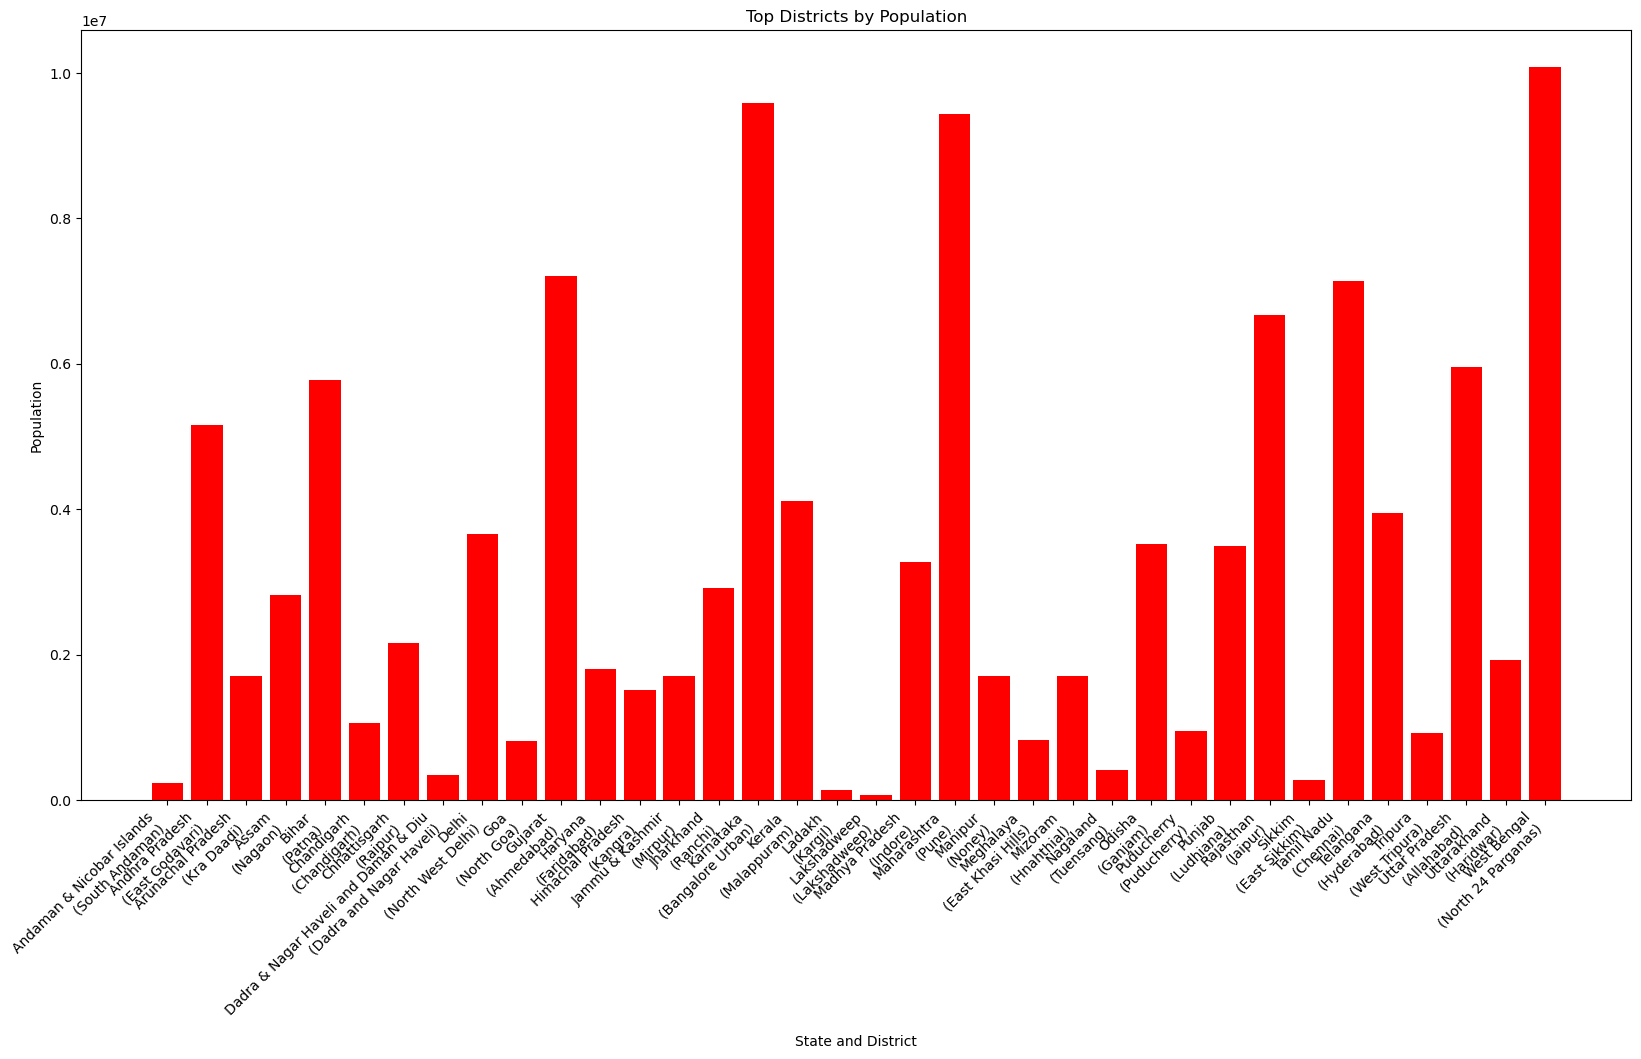

In [116]:
plt.figure(figsize=(20,10))
labels = top_dist['State']+"\n("+ top_dist['District'] + ")"
plt.bar(labels,top_dist['Population'], color = "red")
plt.title("Top Districts by Population")
plt.xlabel("State and District")
plt.ylabel("Population")
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.show()

## 2.5 Calculate the average transaction value (ATV) for each state

#### 2.5.1 Compute the average transaction value for each state. Display the results in a tabular format

In [12]:
avg_atv = df_state_txn_users.groupby('State',as_index = False)['ATV (INR)'].mean().sort_values(by ='ATV (INR)', ascending = False)
avg_atv

,State,ATV (INR)
17,Ladakh,3408.222984
0,Andaman & Nicobar Islands,3159.266422
23,Mizoram,2927.517802
18,Lakshadweep,2776.118701
2,Arunachal Pradesh,2638.323985
21,Manipur,2621.225756
24,Nagaland,2609.942590
13,Jammu & Kashmir,2508.506029
5,Chandigarh,2113.797075
29,Sikkim,2087.843818


#### 2.5.2 Identify the top 5 states with the highest ATV and the top 5 states with the lowest ATV. Display the results

In [14]:
pd.concat([avg_atv.head(),avg_atv.tail()]).reset_index(drop=True)

,State,ATV (INR)
0,Ladakh,3408.222984
1,Andaman & Nicobar Islands,3159.266422
2,Mizoram,2927.517802
3,Lakshadweep,2776.118701
4,Arunachal Pradesh,2638.323985
5,Karnataka,1517.392249
6,Maharashtra,1516.361820
7,Dadra & Nagar Haveli and Daman & Diu,1487.395599
8,Odisha,1428.137367
9,West Bengal,1373.600590


## 2.6 Analyze app usage trends

#### 2.6.1 Calculate the total number of app opens over the years and quarters for each state. Display the results in a tabular format.

In [16]:
app_open_state = df_state_txn_users.groupby(['State','Year','Quarter'],as_index = False)['App Opens'].sum()
app_open_state

,State,Year,Quarter,App Opens
0,Andaman & Nicobar Islands,2018,1,0
1,Andaman & Nicobar Islands,2018,2,0
2,Andaman & Nicobar Islands,2018,3,0
3,Andaman & Nicobar Islands,2018,4,0
4,Andaman & Nicobar Islands,2019,1,0
...,...,...,...,...
499,West Bengal,2020,2,198589332
500,West Bengal,2020,3,246554831
501,West Bengal,2020,4,291721919
502,West Bengal,2021,1,316832674


#### 2.6.2 Identify trends in app usage by creating a line plot showing the number of app opens over time for a selected state.

Enter the name of the state you want to analyze:  Jammu & Kashmir


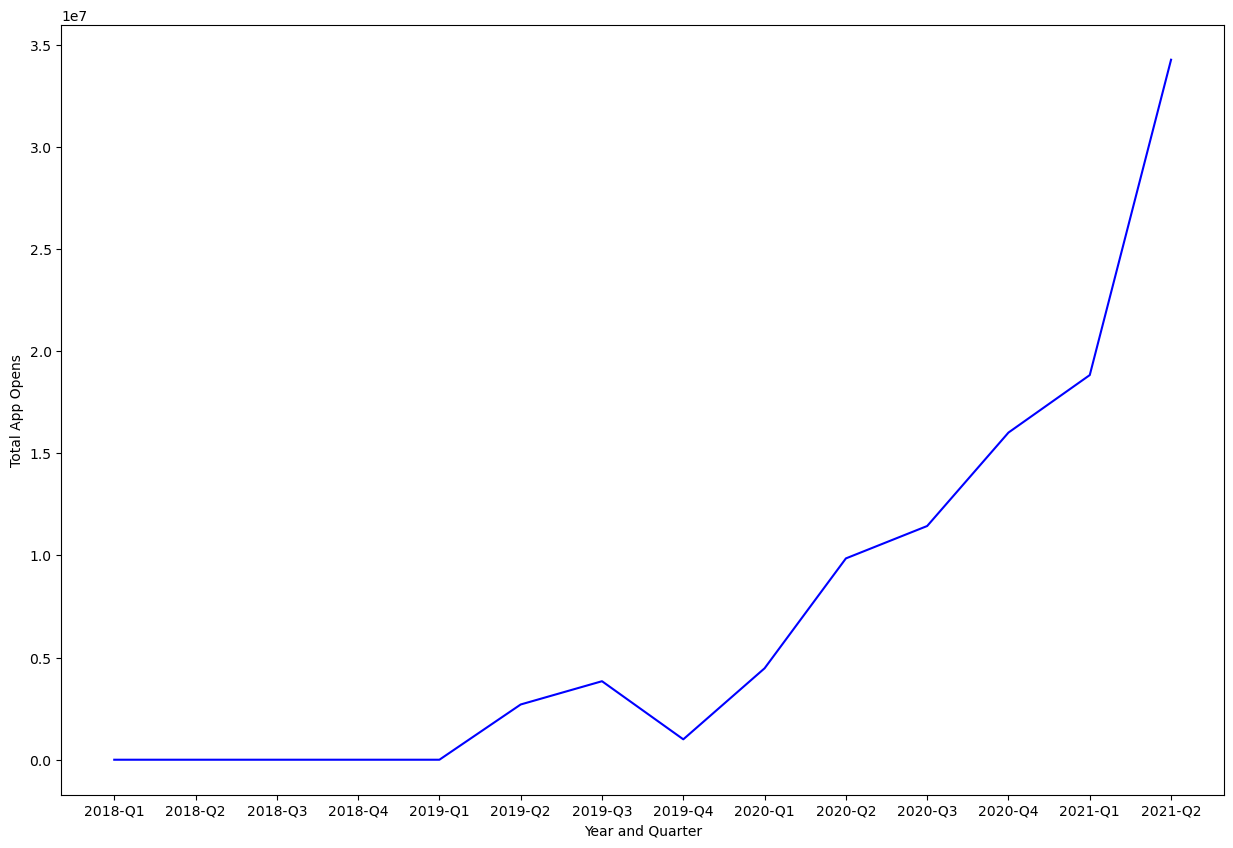

In [30]:
selected_state = input("Enter the name of the state you want to analyze: ").strip().title()
if selected_state in app_open_state['State'].values:
    state_line = app_open_state[app_open_state['State'] == selected_state].copy()
    state_line['Time Period'] = state_line['Year'].astype(str) + '-Q' + state_line['Quarter'].astype(str)

    plt.figure(figsize=(15,10))
    plt.plot(state_line['Time Period'],state_line['App Opens'], color = "blue")
    plt.xlabel("Year and Quarter")
    plt.ylabel("Total App Opens")
    plt.show()
else:
    print(f"State {selected_state} not in database. Please check again")

## 2.7 Distribution of transaction types

#### 2.7.1 Create a bar chart showing the distribution of different transaction types for each state for the most recent quarter in the dataset.

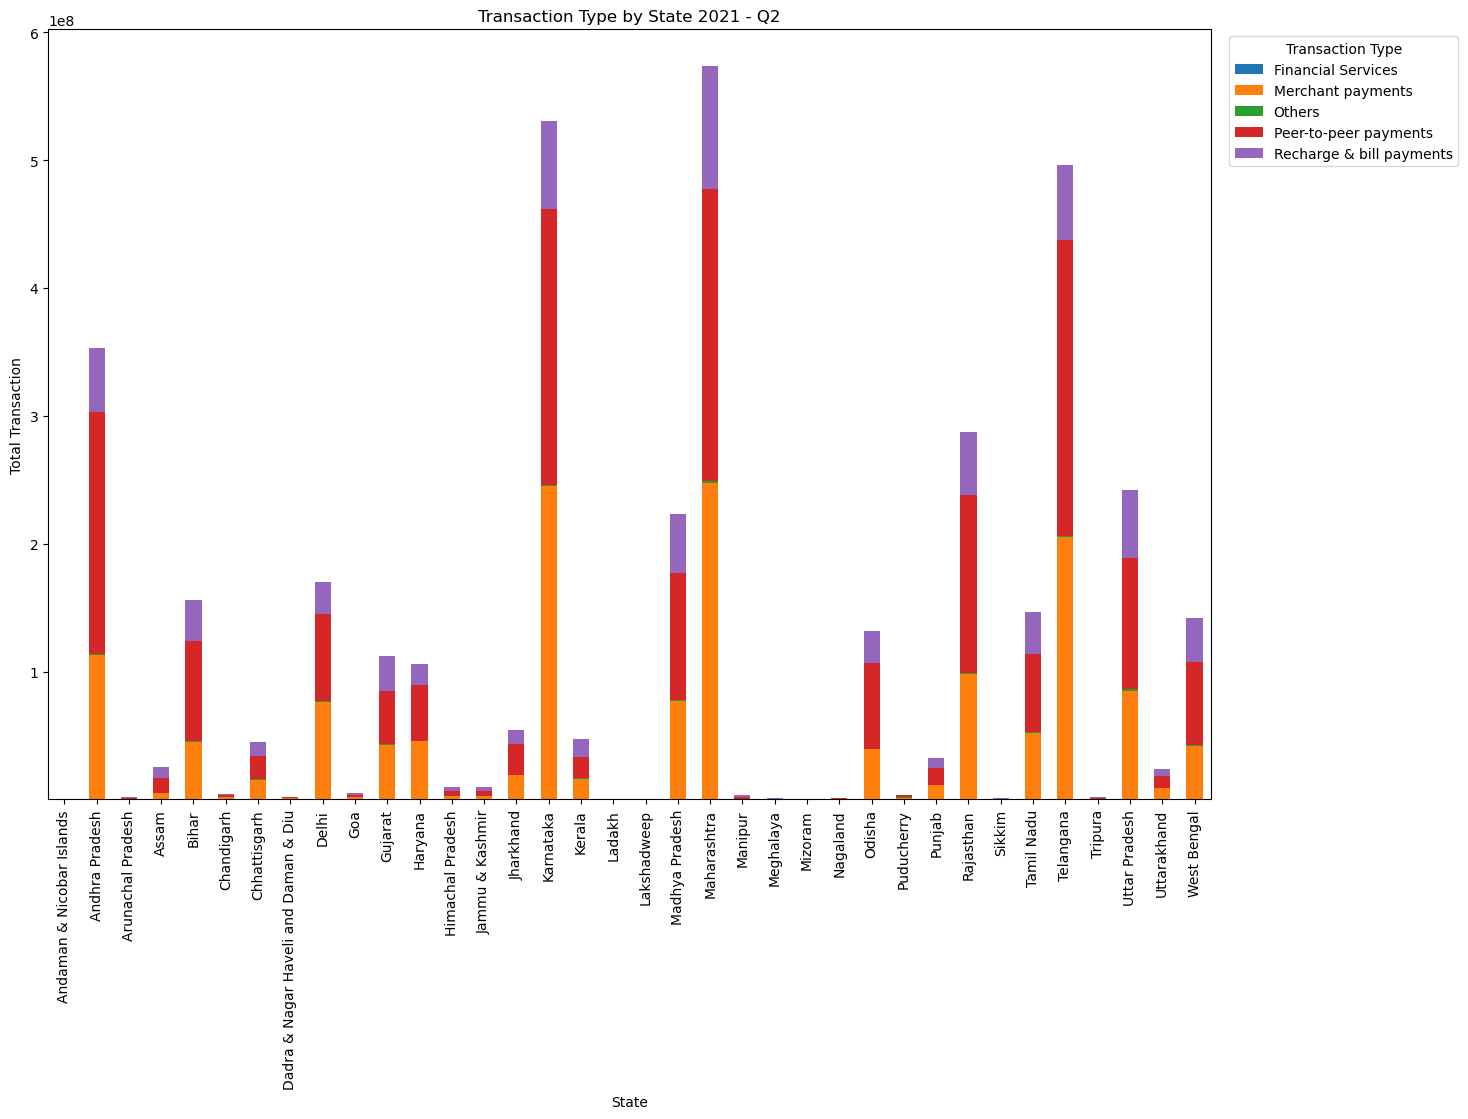

In [40]:
max_year =df_state_txn_category['Year'].max()
max_quarter = df_state_txn_category[df_state_txn_category['Year'] == max_year]['Quarter'].max()
filtered_data = df_state_txn_category[(df_state_txn_category['Year'] == max_year) & (df_state_txn_category['Quarter'] == max_quarter)]
pivot_data = filtered_data.pivot_table(index = 'State',columns = 'Transaction Type', values='Transactions',aggfunc='sum').fillna(0)
pivot_data.plot(kind = 'bar',stacked = True,figsize =(15,10))
plt.title(f"Transaction Type by State {max_year} - Q{max_quarter}")
plt.xlabel('State')
plt.ylabel('Total Transaction')
plt.legend(title='Transaction Type', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.show()

# Data Quality Checks

## 3.1 Ensure data consistency across state and district levels

In [61]:
state_agg = df_state_txn_users.groupby('State', as_index=False)[['Transactions', 'Amount (INR)', 'Registered Users']].sum()
dist_agg=df_dist_txn_users.groupby('State', as_index=False)[['Transactions', 'Amount (INR)', 'Registered Users']].sum()
merged_df = pd.merge(state_agg,dist_agg, on=['State'], suffixes = ('_State','_Dist'))
merged_df['Users_diff'] = abs(merged_df['Registered Users_State'] - merged_df['Registered Users_Dist'])
merged_df['Txn_diff'] = abs(merged_df['Transactions_State'] - merged_df['Transactions_Dist'])
merged_df['Amount_diff'] = round(abs(merged_df['Amount (INR)_State'] - merged_df['Amount (INR)_Dist']),0)
merged_df[['State','Users_diff','Txn_diff','Amount_diff']]

,State,Users_diff,Txn_diff,Amount_diff
0,Andaman & Nicobar Islands,0,0,0.000000e+00
1,Andhra Pradesh,0,0,8.034485e+10
2,Arunachal Pradesh,0,0,0.000000e+00
3,Assam,0,0,0.000000e+00
4,Bihar,0,0,0.000000e+00
5,Chandigarh,0,0,0.000000e+00
6,Chhattisgarh,0,0,0.000000e+00
7,Dadra & Nagar Haveli and Daman & Diu,0,0,0.000000e+00
8,Delhi,0,0,0.000000e+00
9,Goa,0,0,0.000000e+00


# Data Merging and Advanced Analysis

#### 4.1 Ratio of users to population by state

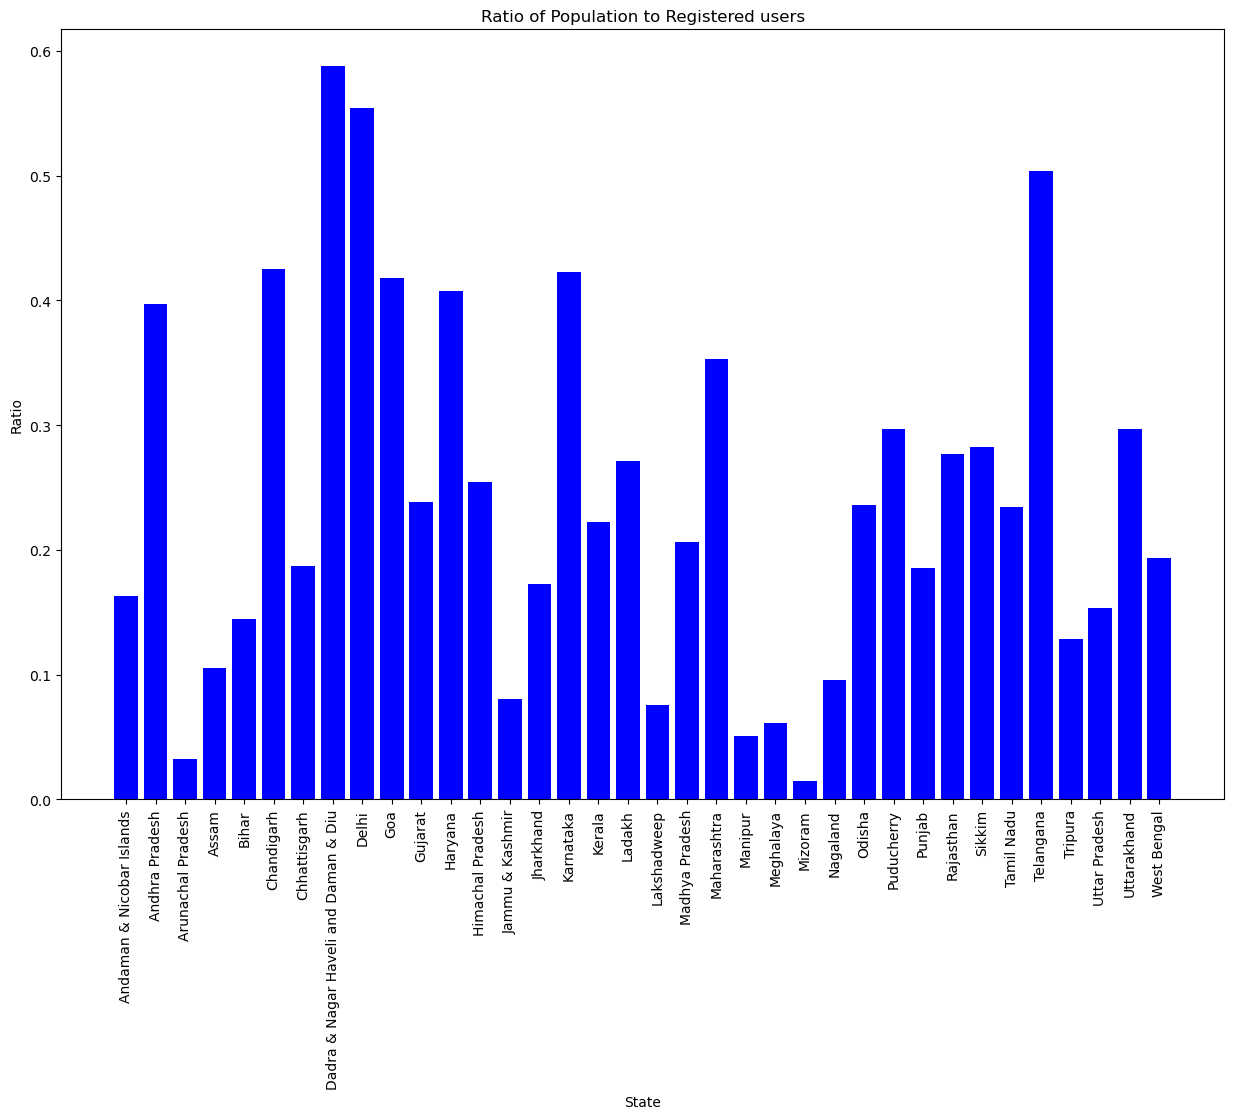

In [76]:
population_grouped = df_dist_demo.groupby('State', as_index = False)['Population'].sum()

max_year =df_state_txn_users['Year'].max()
max_quarter = df_state_txn_users[df_state_txn_users['Year'] == max_year]['Quarter'].max()

filtered_data = df_state_txn_users[(df_state_txn_users['Year'] == max_year) & (df_state_txn_users['Quarter'] == max_quarter)]
state_grouped = filtered_data[['State','Registered Users']]

combined_df = pd.merge(population_grouped,state_grouped, on = ['State'])
combined_df['Ratio'] = combined_df['Registered Users']/combined_df['Population']

plt.figure(figsize=(15,10))
plt.bar(combined_df['State'],combined_df['Ratio'], color = "blue")
plt.title("Ratio of Population to Registered users")
plt.xlabel('State')
plt.ylabel('Ratio')
plt.xticks(rotation=90)
plt.show()

#### 4.2: Correlate population density with transaction volume

Correlation between Population density and Transaction volume is 0.2426


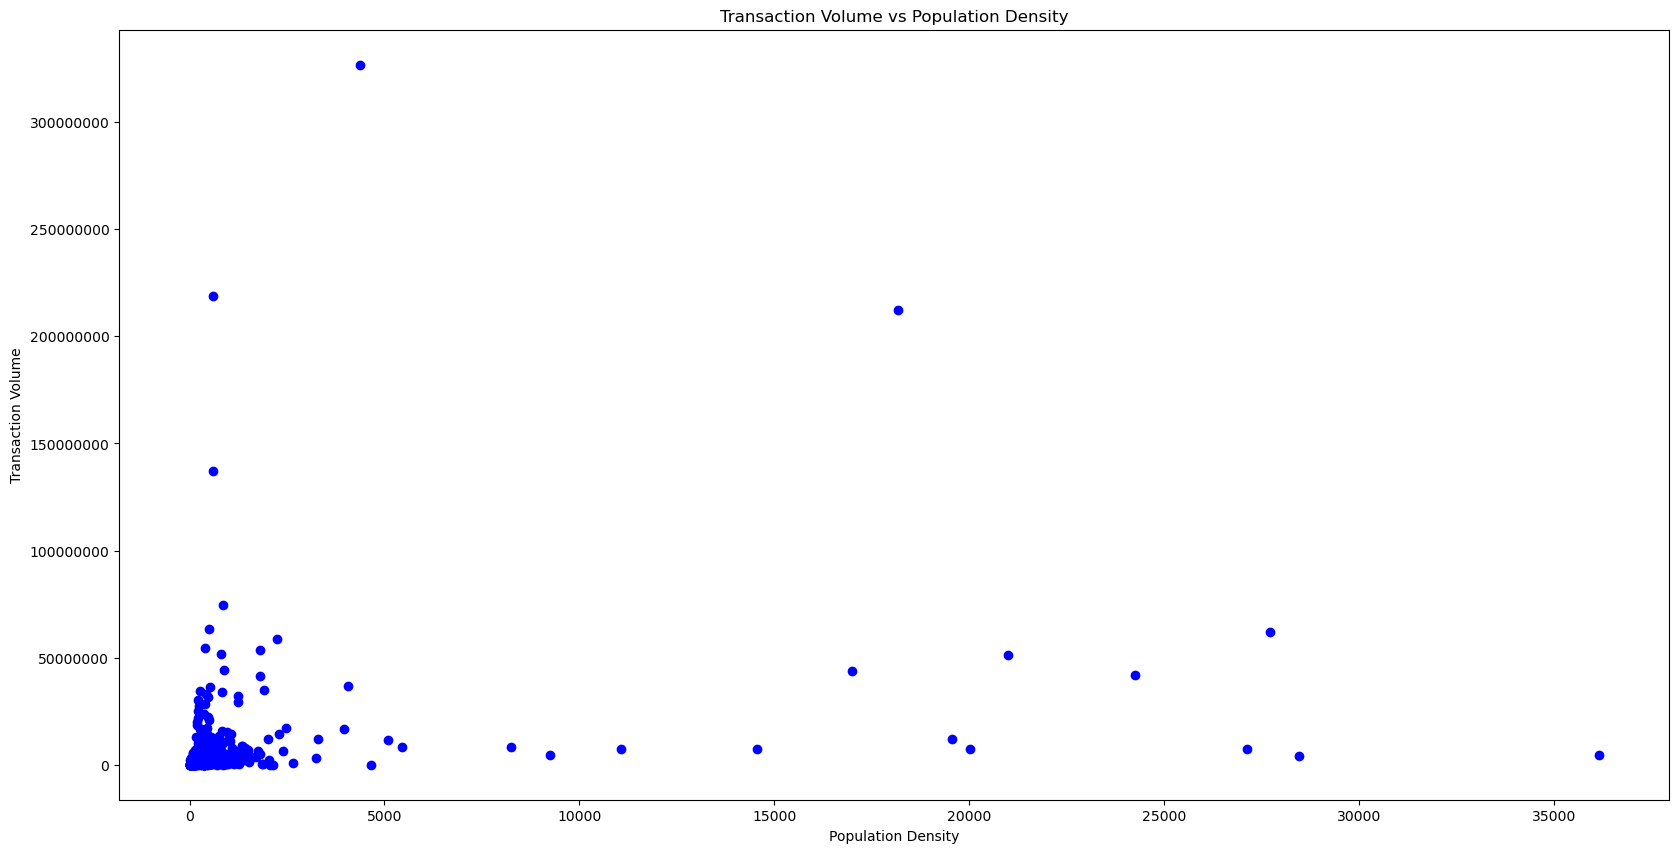

In [45]:
max_year =df_dist_txn_users['Year'].max()
max_quarter = df_dist_txn_users[df_dist_txn_users['Year'] == max_year]['Quarter'].max()
filtered_data = df_dist_txn_users[(df_dist_txn_users['Year'] == max_year) & (df_dist_txn_users['Quarter'] == max_quarter)]
filtered_data_dist = filtered_data[['Code','State','District','Transactions']]
dist_demo_filltered = df_dist_demo[['Code','State','District','Density']]
combined_df = pd.merge(filtered_data_dist,dist_demo_filltered, on = ['Code'],how = "left",suffixes = ('_dist','_demo'))
correlation = combined_df['Transactions'].corr(combined_df['Density'])
print(f"Correlation between Population density and Transaction volume is {correlation.round(4)}")


plt.figure(figsize = (20,10))
plt.scatter(combined_df['Density'],combined_df['Transactions'],c = 'blue')
plt.title("Transaction Volume vs Population Density")
plt.xlabel("Population Density")
plt.ylabel("Transaction Volume")
plt.ticklabel_format(style='plain', axis='both')
plt.show()

#### 4.3 Average transaction amount per user

In [57]:
avg_amount_per_user = df_state_txn_users.groupby('State', as_index = False)[['Amount (INR)','Registered Users']].sum()
avg_amount_per_user['amount_per_user'] = (avg_amount_per_user['Amount (INR)']/avg_amount_per_user['Registered Users']).round(2)
pd.concat([avg_amount_per_user.sort_values(by ='amount_per_user', ascending = False).head(),avg_amount_per_user.sort_values(by ='amount_per_user', ascending = False).tail()]).style.hide(axis="index")

State,Amount (INR),Registered Users,amount_per_user
Telangana,4574245879737.878906,149224214,30653.510000
Andhra Pradesh,3940636991422.510742,158007957,24939.480000
Karnataka,4361395878908.125000,203098564,21474.280000
Rajasthan,2625584351280.978516,149770064,17530.770000
Delhi,1649942211116.078613,95374654,17299.590000
Himachal Pradesh,97865455329.556976,13373980,7317.600000
Kerala,372959870819.685852,51267042,7274.850000
Dadra & Nagar Haveli and Daman & Diu,18658784568.339622,2701112,6907.820000
Tripura,20970514761.531715,3661575,5727.180000
Lakshadweep,192158684.673725,34223,5614.900000


## 4.4: Device brand usage ratio

In [81]:
merged_df = pd.merge(df_state_txn_users,df_state_device_data, on = ['State', 'Year', 'Quarter'],how = "inner",suffixes = ('_s','_d'))
merged_df['Brand_Ratio'] = (merged_df['Registered Users_d']/merged_df['Registered Users_s']).round(3)
pivot_data = merged_df.pivot_table(index='State',columns = 'Brand',values = 'Brand_Ratio', aggfunc = 'mean').fillna(0).round(4)
non_pivot_way = merged_df.groupby(['State','Brand'], as_index = False)['Brand_Ratio'].mean().round(4).head(25)
non_pivot_way

,State,Brand,Brand_Ratio
0,Andaman & Nicobar Islands,Apple,0.0258
1,Andaman & Nicobar Islands,Huawei,0.0278
2,Andaman & Nicobar Islands,Lenovo,0.0212
3,Andaman & Nicobar Islands,Motorola,0.0264
4,Andaman & Nicobar Islands,OnePlus,0.0417
5,Andaman & Nicobar Islands,Oppo,0.0859
6,Andaman & Nicobar Islands,Others,0.0863
7,Andaman & Nicobar Islands,Realme,0.0524
8,Andaman & Nicobar Islands,Samsung,0.1920
9,Andaman & Nicobar Islands,Tecno,0.0150


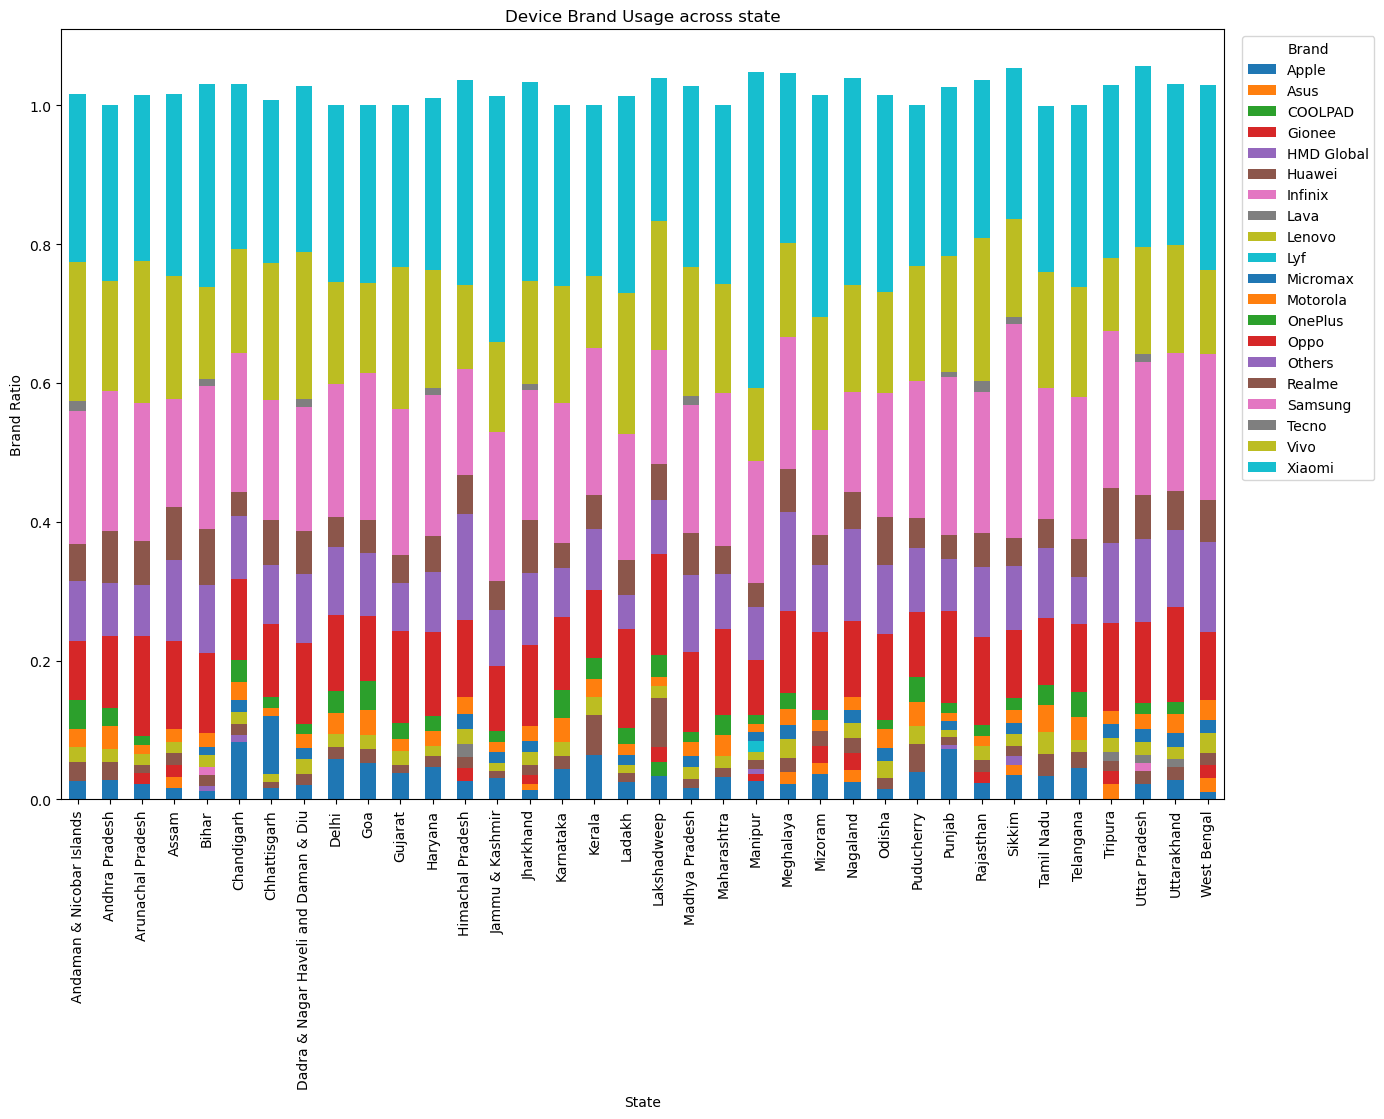

In [84]:
pivot_data.plot(kind = 'bar',stacked = True,figsize =(15,10))
plt.title("Device Brand Usage across state")
plt.xlabel('State')
plt.ylabel('Brand Ratio')
plt.legend(title='Brand', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.show()

# Data Visualisation

## 5.1: Plot the total transactions and amount over time for a selected state

In [85]:
txn_amt_state = df_state_txn_users.groupby(['State','Year','Quarter'],as_index = False)[['Transactions','Amount (INR)']].sum()
txn_amt_state


,State,Year,Quarter,Transactions,Amount (INR)
0,Andaman & Nicobar Islands,2018,1,6658,1.463176e+07
1,Andaman & Nicobar Islands,2018,2,11340,2.833854e+07
2,Andaman & Nicobar Islands,2018,3,16265,5.555747e+07
3,Andaman & Nicobar Islands,2018,4,23758,9.054834e+07
4,Andaman & Nicobar Islands,2019,1,30486,1.022997e+08
...,...,...,...,...,...
499,West Bengal,2020,2,57676797,1.000994e+11
500,West Bengal,2020,3,79954504,1.568134e+11
501,West Bengal,2020,4,100340645,1.991655e+11
502,West Bengal,2021,1,118254052,2.429372e+11


Enter the name of the state you want to analyze:  Maharashtra


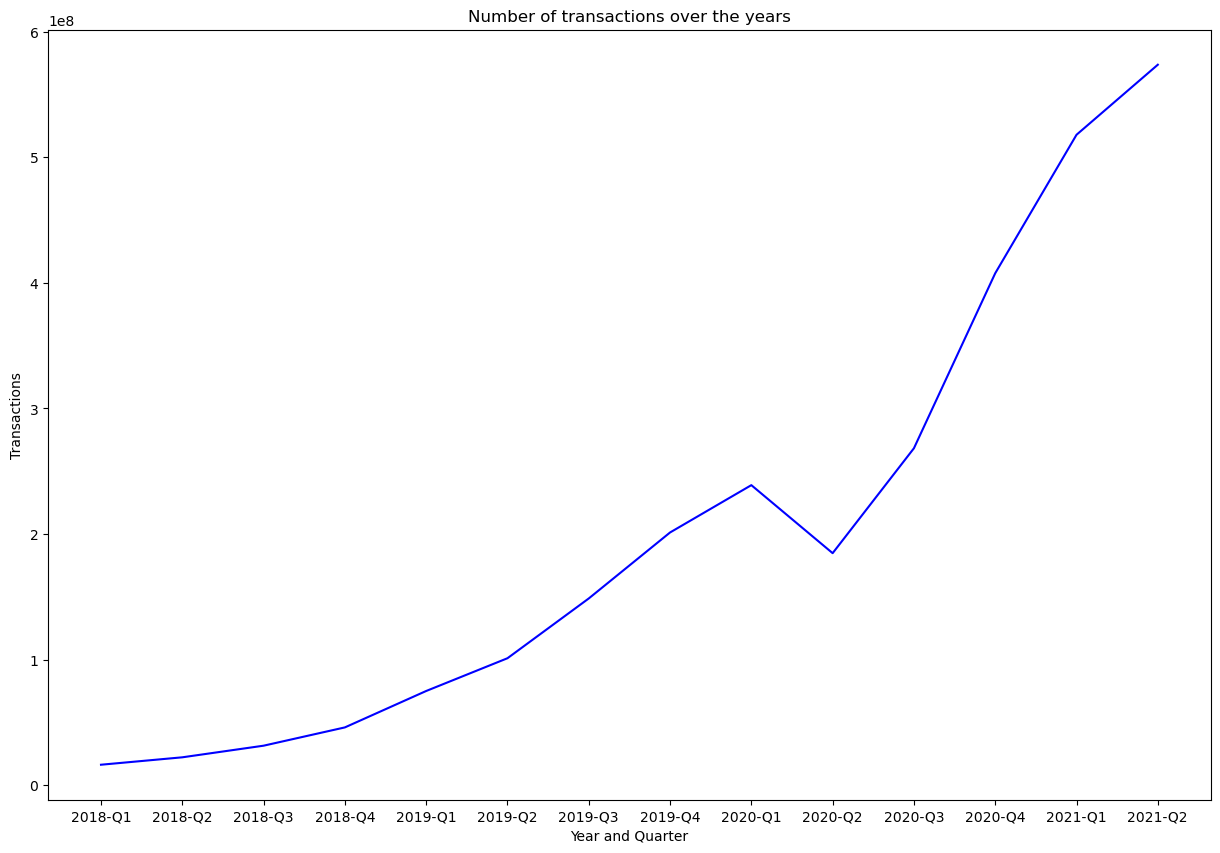

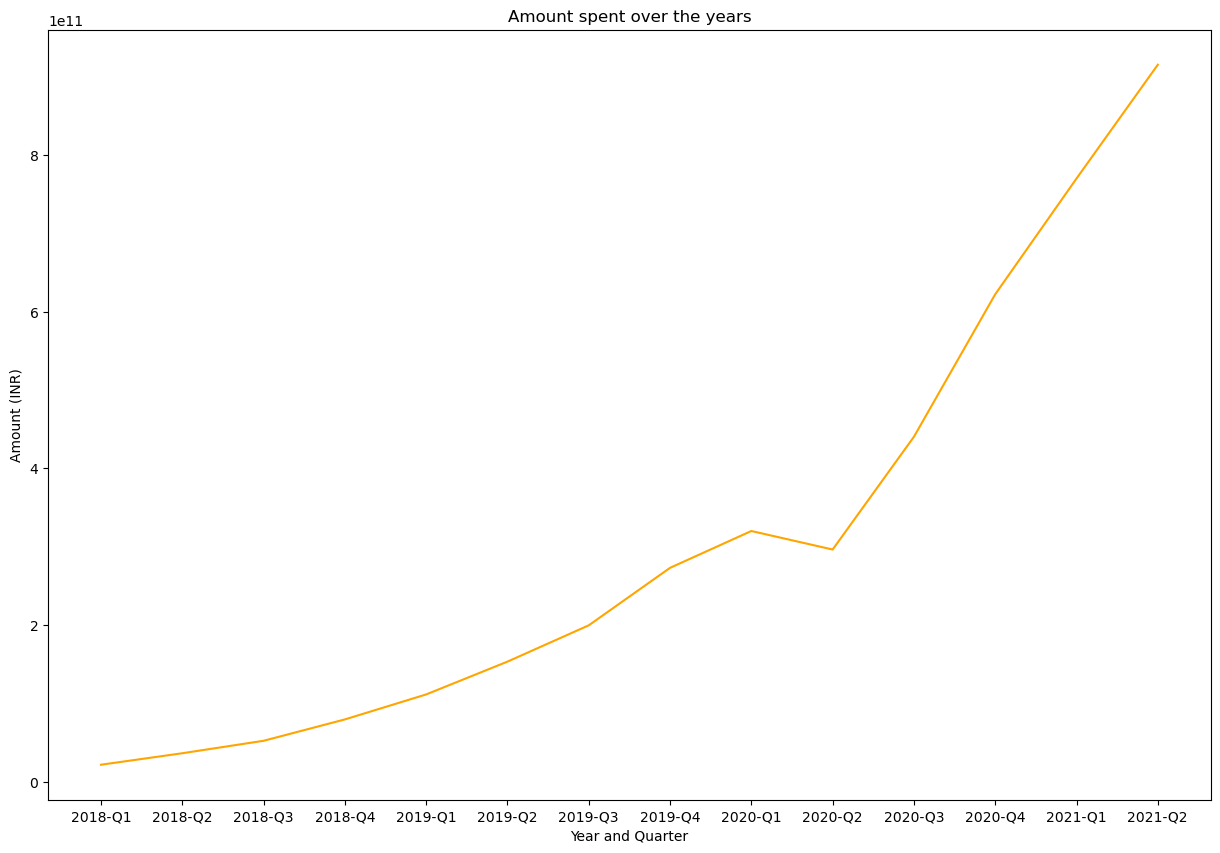

In [93]:
txn_amt_state = df_state_txn_users.groupby(['State','Year','Quarter'],as_index = False)[['Transactions','Amount (INR)']].sum()
selected_state = input("Enter the name of the state you want to analyze: ").strip().title()
if selected_state in txn_amt_state['State'].values:
    state_line = txn_amt_state[txn_amt_state['State'] == selected_state].copy()
    state_line['Time Period'] = state_line['Year'].astype(str) + '-Q' + state_line['Quarter'].astype(str)
    plt.figure(figsize=(15,10))
    plt.title("Number of transactions over the years")
    plt.plot(state_line['Time Period'],state_line['Transactions'], color = "blue")
    plt.xlabel("Year and Quarter")
    plt.ylabel("Transactions")
    plt.show()
else:
    print(f"State {selected_state} not in database. Please check again")

if selected_state in txn_amt_state['State'].values:
    state_line = txn_amt_state[txn_amt_state['State'] == selected_state].copy()
    state_line['Time Period'] = state_line['Year'].astype(str) + '-Q' + state_line['Quarter'].astype(str)
    plt.figure(figsize=(15,10))
    plt.title("Amount spent over the years")
    plt.plot(state_line['Time Period'],state_line['Amount (INR)'], color = "Orange")
    plt.xlabel("Year and Quarter")
    plt.ylabel("Amount (INR)")
    plt.show()
else:
    print(f"State {selected_state} not in database. Please check again")

## 5.2 Create a pie chart showing the distribution of transaction types for a specific quarter

Enter the name of the state you want to analyze:  Maharashtra
Enter the year you want to analyze (between 2018-2021:  2021
Enter the year you want to analyze(1,2,3,4):  2


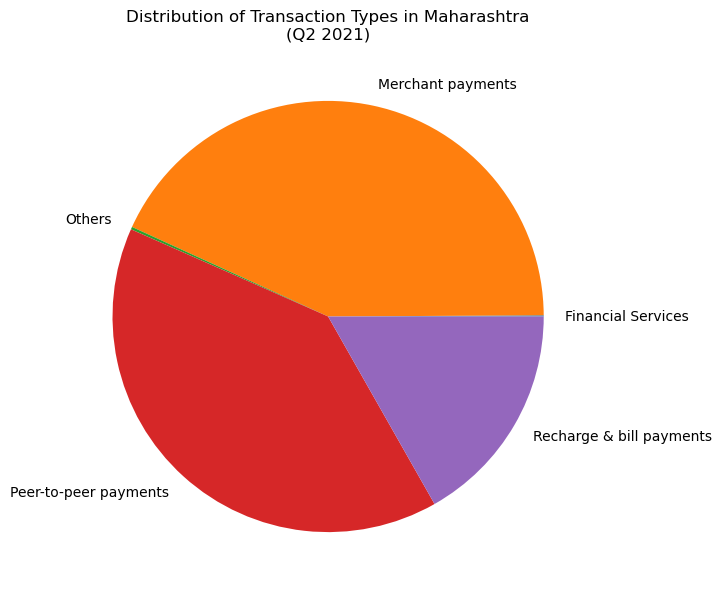

In [101]:
selected_state = input("Enter the name of the state you want to analyze: ").strip().title()
selected_year = int(input("Enter the year you want to analyze (between 2018-2021: ").strip())
selected_quarter = int(input("Enter the year you want to analyze(1,2,3,4): ").strip())
filter_data = df_state_txn_category[
    (df_state_txn_category['State']==selected_state) &
    (df_state_txn_category['Year']== selected_year) &
    (df_state_txn_category['Quarter']== selected_quarter)]
if not filter_data.empty:
    pie_data = filter_data.groupby('Transaction Type')['Transactions'].sum()
    plt.figure(figsize = (7,7))
    plt.pie(pie_data,labels= pie_data.index)
    plt.title(f"Distribution of Transaction Types in {selected_state}\n(Q{selected_quarter} {selected_year})")
    plt.show()
else:
    print("Check Input again")

## 5.3: Visualize the population density of districts in a selected state

Enter the name of the state you want to analyze:  Jammu & Kashmir


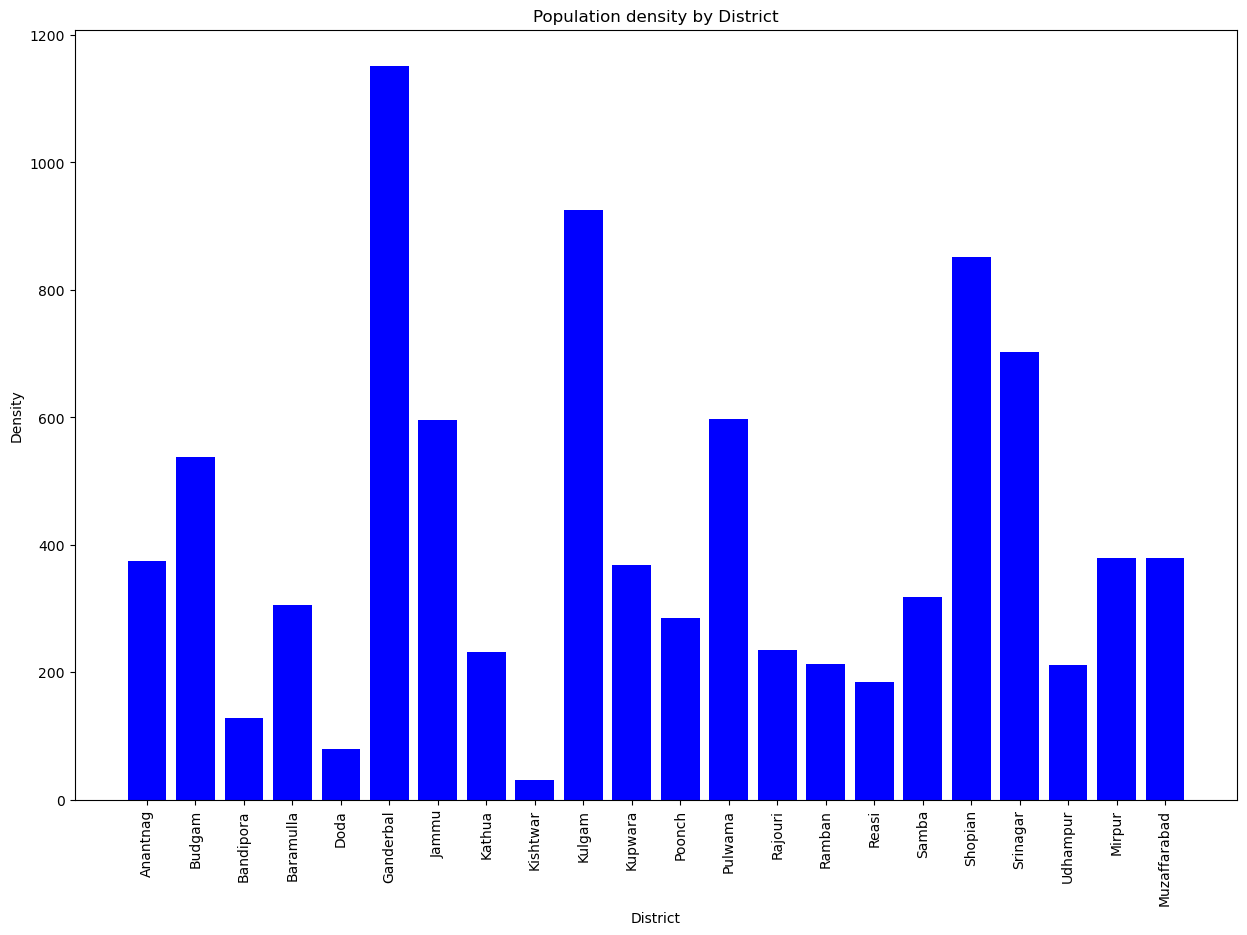

In [103]:
selected_state = input("Enter the name of the state you want to analyze: ").strip().title()
filter_data = df_dist_demo[(df_dist_demo['State']==selected_state)]
if not filter_data.empty:
    plt.figure(figsize=(15,10))
    plt.bar(filter_data['District'],filter_data['Density'], color = "blue")
    plt.title("Population density by District")
    plt.xlabel('District')
    plt.ylabel('Density')
    plt.xticks(rotation=90)
    plt.show()
else:
    print("Check your State")